Project Statement
# Project Statement

## Overview
Develop deep learning models across diverse domains through hands-on projects. This includes the building of an Artificial Neural Network for customer churn prediction using the Banking dataset. Each task addresses distinct real-world challenges involving tabular data, emphasizing model design, data preprocessing, and performance evaluation. This project promote practical understanding of supervised learning through an industry relevant problem, solved using a neural network architecture.

**Input dataset:** [Churn_Modeling.csv](https://media.githubusercontent.com/media/gperdrizet/FSA_devops/refs/heads/main/data/unit4/Churn_Modeling.csv)

---

## Steps to Perform:

### 1. Identify customers who churn the bank:

- **Preprocess the Banking dataset** by removing unnecessary features, encoding categorical variables, and creating training and test splits.
- You can optionally keep this process minimal; we've seen a lot of practice already with Data Wrangling and Feature Engineering, already. However, do make sure to conduct the appropriate amount of EDA, given the dataset and time-constraints, as that may lead to insights into how you can structure your NN.

### 2. Build and Compile a Sequential Artificial Neural Network
- Use Keras with suitable activation functions, optimizer, and loss metrics for churn prediction.
- **NOTE:** If you would like to experiment with hyper-parameter tuning check out KerasTuner

### 3. Explain your choices for:
- Activation Functions
- Optimizers
- Loss metrics
- Network Structure / Architecture

### 4. Train and Evaluate
- Train and Evaluate the model using suitable metrics to measure performance.

### 5. For your trained Neural Network Create and Describe:
- Confusion Matrix
- AUC-ROC Curves
- Precision-Recall Curves

### 6. Reflection
- Write two paragraphs about what you learned.


In [143]:
# imports here
%pip install tensorflow matplotlib pandas scikit-learn --quiet

# Standard library imports
import numpy as np
import pandas as pd

# Third-party imports
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (auc, classification_report, confusion_matrix,
                              precision_recall_curve, roc_curve)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping



In [144]:
# Load the csv into a DataFrame from the project link
url = "https://media.githubusercontent.com/media/gperdrizet/FSA_devops/refs/heads/main/data/unit4/Churn_Modeling.csv"
data = pd.read_csv(url)
print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [145]:
# Seperate features and target
target = 'Exited'
# These non-target columns can be dropped as they are not useful for prediction
X = data.drop(columns=[target, 'RowNumber', 'CustomerId', 'Surname'])
y = data[target]
 # List the remaining columns
print("Feature columns:", X.columns.tolist())

Feature columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [146]:
# Reduce types into the smallest dtypes possible to save memory for ints and floats
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    X[col] = pd.to_numeric(X[col], downcast='unsigned' if X[col].min() >= 0 else 'signed')
    if X[col].dtype == 'float64':
        X[col] = pd.to_numeric(X[col], downcast='float')
    else:
        X[col] = pd.to_numeric(X[col], downcast='integer')
# Preprocess the data and find feature types
# Change male and female in the gender column into boolean dtypes to help processing
X['Gender'] = X['Gender'].map({'Male': True, 'Female': False})

# Identify numeric and categorical features for preprocessing
categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Tenure']
numeric_features = [col for col in X.columns if col not in categorical_features]

print(X.dtypes)
print(X.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

CreditScore          int16
Geography           object
Gender                bool
Age                   int8
Tenure                int8
Balance            float64
NumOfProducts         int8
HasCrCard             int8
IsActiveMember        int8
EstimatedSalary    float64
dtype: object
(10000, 10)
Numeric features: 5
Categorical features: 5


In [147]:
# Now one-hot encode categorical features and standardize numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])
X_processed = preprocessor.fit_transform(X)
print(X_processed.shape)  # Check the shape of the processed features
print(X_processed[:5])  # Display the first 5 rows of processed features

(10000, 20)
[[-0.32622142  0.29351742 -1.22584767 -0.91158349  0.02188649  0.
   0.          0.          1.          1.          0.          1.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [-0.44003595  0.19816383  0.11735002 -0.91158349  0.21653375  0.
   1.          0.          0.          1.          1.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [-1.53679418  0.29351742  1.33305335  2.52705662  0.2406869   0.
   0.          0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          1.
   0.          0.        ]
 [ 0.50152063  0.00745665 -1.22584767  0.80773656 -0.10891792  0.
   0.          0.          0.          0.          1.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 2.06388377  0.38887101  0.7857279  -0.91158349 -0.36527578  0.
   1.          0.     

## Notes so far
- The dataset originally had some useless columns that needed to be dropped giving us 10 features to work with. 5 categorical and 5 numerical.
- Categorical features were one-hot encoded and numerical features were standardized.
    - This changed the overall shape of the data and added overall features due to the one-hot encoding (10 features to 20).

In [148]:
# Setup the Sequential model using the functional API
b_inputs = keras.Input(shape=(X_processed.shape[1],), name='input_layer')
b_x = layers.Dense(64, activation='relu', name='hidden_layer1')(b_inputs)
b_x = layers.Dense(32, activation='relu', name='hidden_layer2')(b_x)
b_outputs = layers.Dense(1, activation='sigmoid', name='output_layer')(b_x)
basic_model = keras.Model(inputs=b_inputs, outputs=b_outputs, name='functional_model')
basic_model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
                loss='mse',
                metrics=['accuracy'])

basic_model.summary()

Model: "functional_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer1 (Dense)           │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

## Notes on thought process
- I was orignally going to train a separate Regression model to compare against, but then I decided to instead make a really simple neural network without much thought going into the architecture just to get a small baseline without any kinds of optimization or hyperparameter tuning.
   - This way I get some extra practice building these models and looking at direct comparisons between different setups and choices in activations, optimizers, and loss functions.

In [149]:
# Uncomment this cell to run, but it will take a while
# Hyperparameter tuning loop

# epochs_list = [25, 50, 75, 100]
# batch_list = [64, 128, 256, 512]
# learning_rate_list = [1e-4, 5e-4, 1e-3, 5e-3]

# best_hyperparams = None
# best_val_loss = float('inf')
# best_val_accuracy = 0.0

# for epochs in epochs_list:
#     for batch_size in batch_list:
#         for lr in learning_rate_list:
#             print(f'Training with epochs={epochs}, batch_size={batch_size}, learning_rate={lr}')
#             #use a unique model each time to avoid weight carryover
#             inputs = keras.Input(shape=(X_processed.shape[1],), name='input_layer')
#             x = layers.Dense(64, activation='relu', name='hidden_layer1')(inputs)
#             x = layers.Dense(32, activation='relu', name='hidden_layer2')(x)
#             outputs = layers.Dense(1, activation='sigmoid', name='output_layer')(x)
#             iter_model = keras.Model(inputs=inputs, outputs=outputs, name='functional_model')
#             iter_model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
#                                 loss='mse',
#                                 metrics=['accuracy'])
#             history = iter_model.fit(
#                 X_processed,
#                 y,
#                 epochs=epochs,
#                 batch_size=batch_size,
#                 validation_split=0.2,
#                 verbose=1
#             )
#             final_val_loss = history.history['val_loss'][-1]
#             final_val_accuracy = history.history['val_accuracy'][-1]
#             print(f'Final validation loss for epochs={epochs}, batch_size={batch_size}, learning_rate={lr}: {final_val_loss:.4f}')
#             print(f'Final validation accuracy for epochs={epochs}, batch_size={batch_size}, learning_rate={lr}: {final_val_accuracy:.4f}')
#             if final_val_loss < best_val_loss and final_val_accuracy > best_val_accuracy:
#                 best_val_loss = final_val_loss
#                 best_val_accuracy = final_val_accuracy
#                 best_hyperparams = (epochs, batch_size, lr)
# print(f'Best hyperparameters: epochs={best_hyperparams[0]}, batch_size={best_hyperparams[1]}, learning_rate={best_hyperparams[2]} with val_loss={best_val_loss:.4f} and val_accuracy={best_val_accuracy:.4f}')
# # Final training with chosen hyperparameters

# print('Training complete.')

In [150]:
# For the basic model I found a good set of hyper parameters to start from
# Best hyperparameters: epochs=100, batch_size=256, learning_rate=0.0005 with val_loss=0.1070 and val_accuracy=0.8565

basic_model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
                loss='mse',
                metrics=['accuracy'])

basic_history = basic_model.fit(
    X_processed,
    y,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
)
print(f'Final training loss: {basic_history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {basic_history.history["val_loss"][-1]:.4f}')
print(f'Final training accuracy: {basic_history.history["accuracy"][-1]:.4f}')

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7447 - loss: 0.2094 - val_accuracy: 0.8050 - val_loss: 0.1662
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7924 - loss: 0.1628 - val_accuracy: 0.8050 - val_loss: 0.1481
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7968 - loss: 0.1466 - val_accuracy: 0.8100 - val_loss: 0.1399
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8012 - loss: 0.1388 - val_accuracy: 0.8205 - val_loss: 0.1332
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8126 - loss: 0.1324 - val_accuracy: 0.8290 - val_loss: 0.1279
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8323 - loss: 0.1249 - val_accuracy: 0.8365 - val_loss: 0.1240
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8371 - loss: 0.1215 - val_accuracy: 0.8370 - val_loss: 0.1210
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8416 - loss: 0.1182 - val_accuracy: 0.8405 - 

In [239]:
# Create another model that is a little more complex by adding more layers, neurons, activation functions, and dropout
# We will also use the base hyperparameters found above to keep a goood starting point

inputs, outputs, x1, x2, x3, x4, merged = None, None, None, None, None, None, None
n1, n2, n3 ,n4 = 128, 64, 64, 128
dr1, dr2, dr3, dr4 = 0.2, 0.3, 0.4, 0.4
a1, a2, a3, a4 = 'relu', 'mish', 'swish', 'relu'
print(X_processed.shape[1])
inputs = keras.Input(shape=(X_processed.shape[1],), name='input_layer')
x1 = layers.Dense(n1, activation=a1, name='hidden_layer1')(inputs)
x1 = layers.Dropout(dr1, name='dropout1')(x1)
x1 = layers.Dense(n2, activation=a1, name='hidden_layer2')(x1)
x1 = layers.Dropout(dr2, name='dropout2')(x1)
x1 = layers.Dense(n3, activation=a1, name='hidden_layer3')(x1)
x1 = layers.Dropout(dr3, name='dropout3')(x1)
x1 = layers.Dense(n4, activation=a1, name='hidden_layer4')(x1)
x1 = layers.Dropout(dr4, name='dropout4')(x1)
x2 = layers.Dense(n1, activation=a2, name='hidden_layer5')(inputs)
x2 = layers.Dropout(dr1, name='dropout5')(x2)
x2 = layers.Dense(n2, activation=a2, name='hidden_layer6')(x2)
x2 = layers.Dropout(dr2, name='dropout6')(x2)
x2 = layers.Dense(n3, activation=a2, name='hidden_layer7')(x2)
x2 = layers.Dropout(dr3, name='dropout7')(x2)
x2 = layers.Dense(n4, activation=a2, name='hidden_layer8')(x2)
x2 = layers.Dropout(dr4, name='dropout8')(x2)
x3 = layers.Dense(n1, activation=a3, name='hidden_layer9')(inputs)
x3 = layers.Dropout(dr1, name='dropout9')(x3)
x3 = layers.Dense(n2, activation=a3, name='hidden_layer10')(x3)
x3 = layers.Dropout(dr2, name='dropout10')(x3)
x3 = layers.Dense(n3, activation=a3, name='hidden_layer11')(x3)
x3 = layers.Dropout(dr3, name='dropout11')(x3)
x3 = layers.Dense(n4, activation=a3, name='hidden_layer12')(x3)
x3 = layers.Dropout(dr4, name='dropout12')(x3)
print(x1.shape)
print(x2.shape)
print(x3.shape)
merged = layers.Concatenate(name='concatenate_merge')([x1, x2, x3])
averaged = layers.Average(name='average_merge')([x1, x2, x3])
print(merged.shape)
x4 = layers.Dense(n2, activation=a4, name='hidden_layer13')(merged)
x4 = layers.Dropout(dr1, name='dropout13')(x4)
x4 = layers.Dense(n3, activation=a4, name='hidden_layer14')(x4)
# x4 = layers.Dropout(dr1, name='dropout14')(x4)
# x5 = layers.Dense(n2, activation=a4, name='hidden_layer15')(averaged)
# x5 = layers.Dropout(dr1, name='dropout15')(x5)
# x5 = layers.Dense(n3, activation=a4, name='hidden_layer16')(x5)
# x5 = layers.Dropout(dr1, name='dropout16')(x5)
# combined = layers.Concatenate(name='final_concatenate')([x4, x5])
# x6 = layers.Dense(n2, activation=a4, name='final_hidden_layer')(combined)
# x6 = layers.Dropout(dr1, name='final_dropout')(x6)
# x6 = layers.Dense(n3, activation=a4, name='final_hidden_layer2')(x6)
# x6 = layers.Dropout(dr1, name='final_dropout2')(x6)
outputs = layers.Dense(1, activation='sigmoid', name='output_layer')(x4)
functional_model = keras.Model(inputs=inputs, outputs=outputs, name='functional_model')
optim = keras.optimizers.AdamW(learning_rate=4e-3,
                               weight_decay=6e-3,
                               beta_1=0.7,
                               beta_2=0.999,
                               amsgrad=True,
                               use_ema=True,
                               ema_momentum=0.777,
                               ema_overwrite_frequency=None
                               )
functional_model.compile(optimizer=optim,
                loss='binary_focal_crossentropy',
                metrics=['accuracy', 'Precision', 'Recall', 'binary_crossentropy'])

functional_model.summary()

# Create early stop callback
early_stop = EarlyStopping(
    monitor='val_binary_crossentropy',
    patience=20,
    restore_best_weights=True,
    start_from_epoch=69,
    verbose=1
)

20
(None, 128)
(None, 128)
(None, 128)
(None, 384)


Model: "functional_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer1       │ (None, 128)       │      2,688 │ input_layer[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer5       │ (None, 128)       │      2,688 │ input_layer[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer9       │ (None, 128)       │      2,688 │ input_layer[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 128)       │          0 │ hidden_layer1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout5 (Dropout)  │ (None, 128)       │          0 │ hidden_layer5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout9 (Dropout)  │ (None, 128)       │          0 │ hidden_layer9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer2       │ (None, 64)        │      8,256 │ dropout1[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer6       │ (None, 64)        │      8,256 │ dropout5[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer10      │ (None, 64)        │      8,256 │ dropout9[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 64)        │          0 │ hidden_layer2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout6 (Dropout)  │ (None, 64)        │          0 │ hidden_layer6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout10 (Dropout) │ (None, 64)        │          0 │ hidden_layer10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer3       │ (None, 64)        │      4,160 │ dropout2[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer7       │ (None, 64)        │      4,160 │ dropout6[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer11      │ (None, 64)        │      4,160 │ dropout10[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout3 (Dropout)  │ (None, 64)        │          0 │ hidden_layer3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout7 (Dropout)  │ (None, 64)        │          0 │ hidden_layer7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout11 (Dropout) │ (None, 64)        │          0 │ hidden_layer11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer4       │ (None, 128)       │      8,320 │ dropout3[0][0]  

 Total params: 99,137 (387.25 KB)

 Trainable params: 99,137 (387.25 KB)

 Non-trainable params: 0 (0.00 B)

In [243]:
# Train the functional model with early stopping
functional_history = functional_model.fit(
    X_processed,
    y,
    epochs=200,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - Precision: 0.8109 - Recall: 0.7113 - accuracy: 0.9025 - binary_crossentropy: 0.2702 - loss: 0.0545 - val_Precision: 0.6383 - val_Recall: 0.4615 - val_accuracy: 0.8440 - val_binary_crossentropy: 0.4055 - val_loss: 0.1481
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - Precision: 0.8385 - Recall: 0.6521 - accuracy: 0.9037 - binary_crossentropy: 0.2930 - loss: 0.0593 - val_Precision: 0.5965 - val_Recall: 0.5308 - val_accuracy: 0.8385 - val_binary_crossentropy: 0.4293 - val_loss: 0.1232
Epoch 3/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - Precision: 0.7919 - Recall: 0.6769 - accuracy: 0.8983 - binary_crossentropy: 0.2959 - loss: 0.0583 - val_Precision: 0.6438 - val_Recall: 0.4821 - val_accuracy: 0.8470 - val_binary_crossentropy: 0.4096 - val_loss: 0.1263
Epoch 4/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - Precision: 0.8154 - Recall: 0.6787 - accuracy: 0.9036 - binary_crossentropy: 0.2949 - loss: 0.0592 - val_Precision: 0.6541 -

In [244]:
# Print final training results and plot the confusion matrix, Precision-Recall and ROC curves and their AUCs.
print(f'Final training loss: {functional_history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {functional_history.history["val_loss"][-1]:.4f}')
print(f'Final training accuracy: {functional_history.history["accuracy"][-1]:.4f}')
print(f'Final validation accuracy: {functional_history.history["val_accuracy"][-1]:.4f}')
print(f'Final training Precision: {functional_history.history["Precision"][-1]:.4f}')
print(f'Final validation Precision: {functional_history.history["val_Precision"][-1]:.4f}')
print(f'Final training Recall: {functional_history.history["Recall"][-1]:.4f}')
print(f'Final validation Recall: {functional_history.history["val_Recall"][-1]:-.4f}')

Final training loss: 0.0428
Final validation loss: 0.1892
Final training accuracy: 0.9293
Final validation accuracy: 0.8165
Final training Precision: 0.8445
Final validation Precision: 0.5291
Final training Recall: 0.8045
Final validation Recall: 0.5359


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Confusion Matrix:
[[7713  250]
 [ 344 1693]]


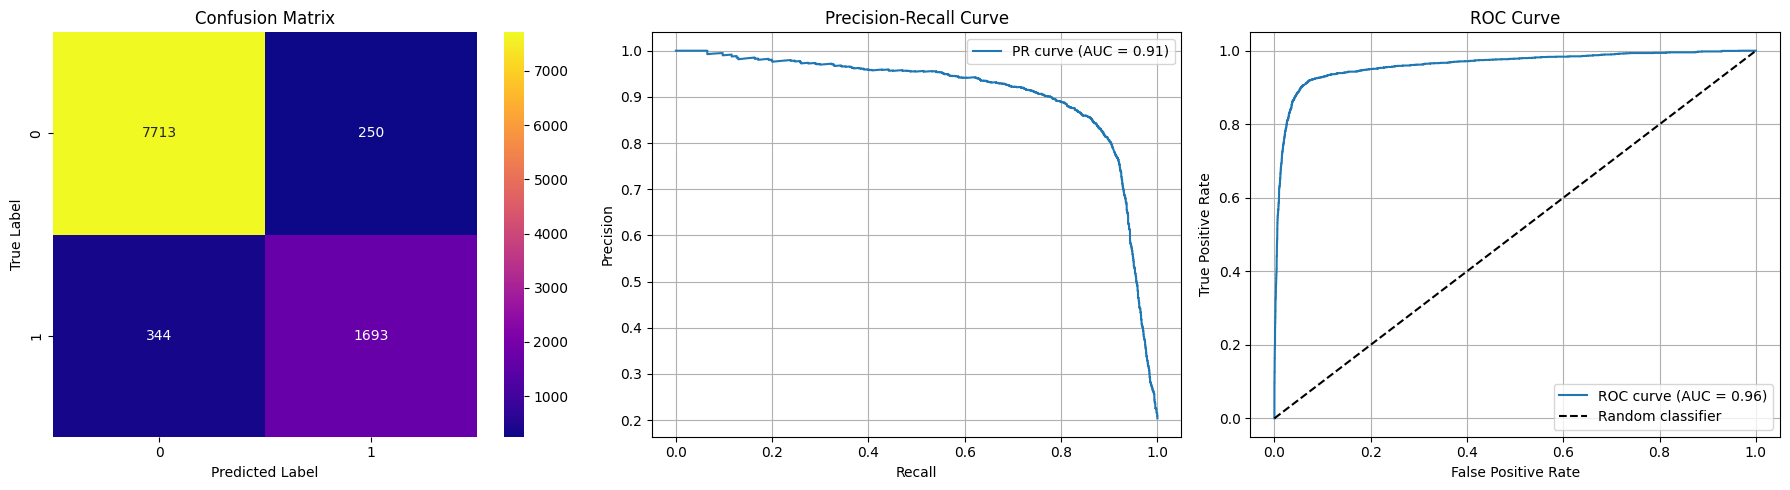

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Confusion Matrix (Training Data):
[[7713  250]
 [ 344 1693]]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


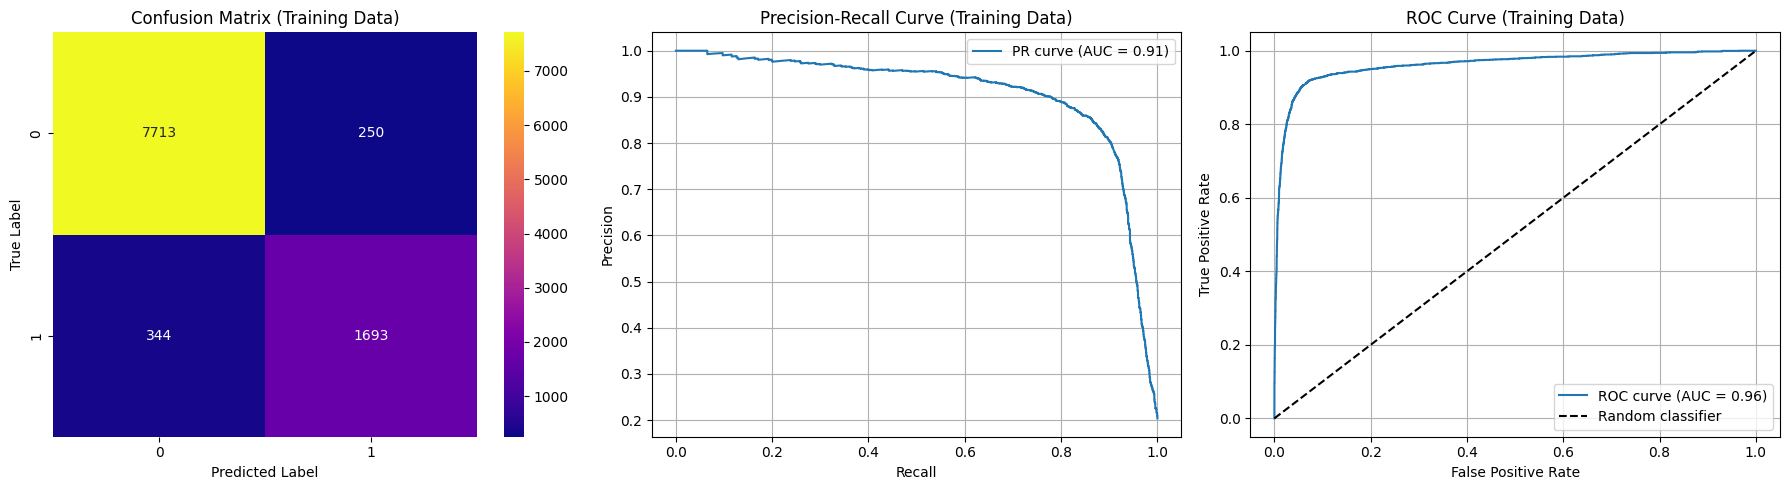

In [246]:
# Generate predictions
y_pred_proba = functional_model.predict(X_processed)
y_pred = (y_pred_proba > 0.5).astype("int32")

# Create a figure with all three plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='plasma', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y, y_pred_proba)
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True)

# ROC curve
fpr, tpr, _ = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], 'k--', label='Random classifier')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Then we plot the same graphs but for the training data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Confusion matrix
cm = confusion_matrix(y, (functional_model.predict(X_processed) > 0.5).astype("int32"))
print("\nConfusion Matrix (Training Data):")
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='plasma', ax=axes[0])
axes[0].set_title('Confusion Matrix (Training Data)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y, functional_model.predict(X_processed))
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Training Data)')
axes[1].legend()
axes[1].grid(True)
# ROC curve
fpr, tpr, _ = roc_curve(y, functional_model.predict(X_processed))
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], 'k--', label='Random classifier')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve (Training Data)')
axes[2].legend()
axes[2].grid(True)
plt.tight_layout()
plt.show()

## Initial notes
- Values of the first run: 
    - Final training loss: 0.0771
    - Final validation loss: 0.1206
    - Final training accuracy: 0.9040
    - Final validation accuracy: 0.8515
- The confusion matrix shows approximately a 10% failure rate in both false positives and false negatives.
- The Precision-Recall curve looks like I could push the curve higher with some tuning.
- The ROC curve is decent, but again could be improved with some tuning.

## Updated training with Early Stopping
- Added Early Stopping with patience of 4 epochs monitoring validation loss.
- I couldn't make better models than the initial, very simple, model. Anything complicated or deeper would overfir, train poorly, or just fail making anything other than single output predictions
- I think I should probably keep playing around with this and not try to make too much of a complicated model. The dataset is small and simple enough that a complex model isn't necessary.
- I could also probably be doing something incorrectly with the data preprocessing or model building/training process.